<a href="https://colab.research.google.com/github/gautamkushwaha/50-days-of-coding/blob/main/Day_1_mnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST In pytorch - absolute beginner
0. install the dependencies(torch, torchvision)
1. import libraries
- pytorch(torch) ,
- neural network tools(torch.nn as nn),
- torch.optim as optim for optimizer like Adam, SGD,
- from torchvision import datasets, transform ,
- datasets ready-made datasets like MNIST, and transform - operation applied to images(to convert to tensor)
- from toruch.utils.data import DataLoader, load the data in batches instead of all at once

In [1]:
!pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


2. Choose device(CPU Or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
means if GPU is available use it or use the cpu

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

3. Prepare the MNIST dataset

transform = transform.ToTensor()

 converting image from (0-255) to tensor(0-1), neural network only understsand numbers

In [4]:
transform = transforms.ToTensor()

4. Training Dataset
   
   train_dataset = datasets.MNIST(root = "./data", train= True, download = True, transform = transform)

   root = "./data" where the dataset is saved
   train = True  training data(60,000 images)
   download = True downloads if not present
   transform = trandform apply ToTensor()

In [5]:
train_dataset = datasets.MNIST(root="./data", train= True, download= True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 548kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


Test dataset:
test_dataset = datasets.MNIST(root

In [6]:
test_dataset = datasets.MNIST(root="./data", train = False, download=True, transform=transform)

4. DataLoader(batching)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle= True)

- takes 64 images at a time
- shuffle = True random order (important for learning)

- no shuffle for test dataset because order doesn't matter


In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle =False)

In [8]:
for images, labels in train_loader:
    print(f"Shape of images in a batch: {images.shape}")
    print(f"Shape of labels in a batch: {labels.shape}")
    print(f"First 5 labels in the batch: {labels[:5]}")
    break # We only want to see one batch as an example

Shape of images in a batch: torch.Size([64, 1, 28, 28])
Shape of labels in a batch: torch.Size([64])
First 5 labels in the batch: tensor([8, 9, 7, 0, 7])


Number of samples in the test dataset: 10000

Shape of a single image: torch.Size([1, 28, 28])
Label of the sample image: 1


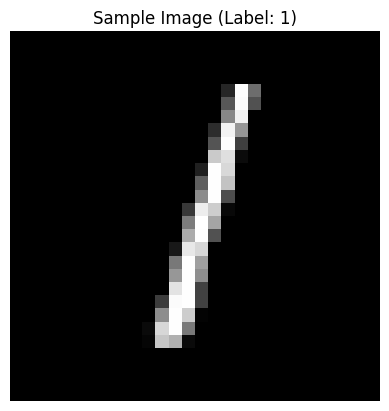

In [9]:
print(f"Number of samples in the test dataset: {len(test_dataset)}")

# Get one sample (image and label) from the test dataset
# Datasets are indexable, unlike DataLoaders
sample_image, sample_label = test_dataset[2]

print(f"\nShape of a single image: {sample_image.shape}")
print(f"Label of the sample image: {sample_label}")

# You can also visualize the image (optional)
# For visualization, we often need to convert the tensor back to a format matplotlib can display
import matplotlib.pyplot as plt

# Squeeze the channel dimension if it's 1 (for grayscale) and move to CPU
plt.imshow(sample_image.squeeze().cpu().numpy(), cmap='gray')
plt.title(f"Sample Image (Label: {sample_label})")
plt.axis('off')
plt.show()

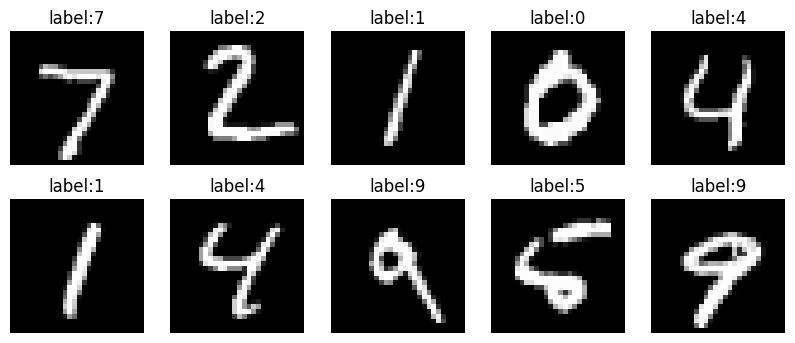

In [10]:
count = 0
fig, axes = plt.subplots(2, 5, figsize=(10,4))
axes = axes.flatten()
for i, (sample_images, label) in enumerate(test_dataset):
  axes[i].imshow(sample_images.squeeze().cpu().numpy(), cmap='gray')
  axes[i].set_title(f"label:{label}")
  axes[i].axis('off')


  count +=1
  if count == 10:
    break
plt.show()

This output shows:

*   **`Number of samples in the test dataset:`**: The total number of images in your test set (typically 10,000 for MNIST).
*   **`Shape of a single image:`**: For MNIST, this will be `torch.Size([1, 28, 28])`, meaning 1 channel (grayscale), 28 pixels high, and 28 pixels wide. It's a tensor with values scaled between 0 and 1, as applied by `transforms.ToTensor()`.
*   **`Label of the sample image:`**: The actual digit (0-9) that the image represents.

The `matplotlib` code block visualizes the first image from the dataset, which helps confirm the data is loaded correctly and appears as expected.

In [14]:
# # Instantiate the model
# model = SimpleNN().to(device)

# # Define Loss and Optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# print("Model instantiated and moved to device:")
# print(model)
# print(f"\nLoss function: {criterion}")
# print(f"Optimizer: {optimizer}")

Model instantiated and moved to device:
SimpleNN(
  (fc): Linear(in_features=784, out_features=10, bias=True)
)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


The output shows:
- `images.shape`: This is `[batch_size, channels, height, width]`. For MNIST, it's typically `[64, 1, 28, 28]` meaning 64 images, 1 color channel (grayscale), 28 pixels high, and 28 pixels wide.
- `labels.shape`: This is `[batch_size]`, which for MNIST is `[64]`, representing 64 corresponding labels (the actual digits 0-9) for each image in the batch.
- `labels[:5]`: This shows the first 5 labels in that particular batch.

In [ ]:
train_loader

Lets define the neural network

- create a neural network class

- must inherit from nn.Module

- def __init__(self) - constructor of the class
- super().__init__() - super() initializes parent class (nn.module)
- fully connected (Linear) layer
- input 28 * 28 = 784 pixels
- output : 10 classes (digits 0-9)

-   def forward(self,x): - define how data flows through the network

In [12]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.fc= nn.Linear(28*28, 10)

  def forward(self,x):
    x = x.view(x.size(0), -1) # flattens images [ 64, 1, 28, 28] -> [ 64, 784]
    return self.fc(x)

6. Create the model

- create the neural network
- moves it to cpu or gpu



In [15]:
model = SimpleNN().to(device)

7. Loss Function
- measures how wrong the prediction is
- Used for classification problem
- multiclass classification CrossEntropyLoss

In [16]:
criterion = nn.CrossEntropyLoss()

8. Optimizer(Adam)
- Adam optimizer updates weights with momentum
- lr = 0.001 -> learning rate

# What is model.parameters()?

👉 It returns all the trainable parameters of your model

That means:

weights

biases
that have requires_grad = True

In [17]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

9. Training loop
- one epoch = one full pass over training data
- train for 5 epochs
- model.train() - tells Pytorch ,"I'm training now"
- total_loss = 0 : stores loss for this epoch
- training batches: for images, lables in train_loader, loads one batch of images and lables
- moves data to same device as model: images, labels = images.to(device), labels.to(device)
- optimizer.zero_grad() - clear old gradients(important) why?
- outputs = model(images) - forward pass, model proedict digit scores
- loss = criterion(outputs, labels) : computes error between prediction and true label
- loss.backward()  : backpropagation, compute gradient
- optimizer.step() - updates weights using Adam
- total_loss += loss.item(). : adds batch loss to total
-  print(f"Epoch [{epoch +1}/5]. Loss: {total_loss:.4f}"): Prints training progress

In [23]:
for epoch in range(5):
  model.train()
  total_loss = 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    output= model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(f"Epoch [{epoch +1}/5]. Loss: {total_loss:.4f}")

Epoch [1/5]. Loss: 264.0916
Epoch [2/5]. Loss: 262.1649
Epoch [3/5]. Loss: 260.3566
Epoch [4/5]. Loss: 262.5606
Epoch [5/5]. Loss: 262.5740


🔹 10. Testing (Evaluation)
- Switches model to evaluation mode
- correct = 0, total = 0 are counters for accuracy
- with torch.no_grad():  saves memory (no gradients needed)
- for images, labels in test_loader : loop through test data
- outputs = model(images) : predict digits
- _, predicted = torch.max(outputs, 1) ; selects digit with highest score
- correct += (predicted == labels).sum().item() : counts correct prediction
- total number of samples: total += labels.size(0)
- prints final accuracy

In [21]:
model.eval()
correct = 0
total =0
for images, labels in test_loader:
  images , labels = images.to(device), labels.to(device)
  output= model(images)
  _,predicted = torch.max(output, 1)
  correct +=(predicted == labels).sum().item()
  total +=labels.size(0)

print(f"Test Accuracy: {100 * correct /total:.2f}%")

Test Accuracy: 91.35%
